In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

X = iris.data
y = iris.target

df = pd.concat([X, pd.Series(y, name='target')], axis=1)

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeature names:', iris.feature_names)
print('Target names:', iris.target_names.tolist())

df.head()

Features shape: (150, 4)
Target shape: (150,)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_classifier.fit(X_train, y_train)

# Predict
y_pred = rf_classifier.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [3]:
import os
import joblib
import pickle
import json

os.makedirs('models', exist_ok=True)

# Save joblib model
joblib.dump(rf_classifier, 'models/iris_model.joblib')

# Save pickle model
with open('models/iris_model.pickle', 'wb') as f:
    pickle.dump(rf_classifier, f)

# Save metadata
model_info = {
    'model_type': 'RandomForestClassifier',
    'accuracy': float(acc),
    'feature_names': iris.feature_names,
    'target_names': iris.target_names.tolist()
}

with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

# Feature ranges for Streamlit sliders
feature_ranges = {
    'sepal_length': {'min': float(X['sepal length (cm)'].min()), 'max': float(X['sepal length (cm)'].max()), 'default': 5.8},
    'sepal_width': {'min': float(X['sepal width (cm)'].min()), 'max': float(X['sepal width (cm)'].max()), 'default': 3.0},
    'petal_length': {'min': float(X['petal length (cm)'].min()), 'max': float(X['petal length (cm)'].max()), 'default': 4.0},
    'petal_width': {'min': float(X['petal width (cm)'].min()), 'max': float(X['petal width (cm)'].max()), 'default': 1.2}
}

with open('models/feature_ranges.json', 'w') as f:
    json.dump(feature_ranges, f, indent=2)

print("Model files saved successfully!")

Model files saved successfully!


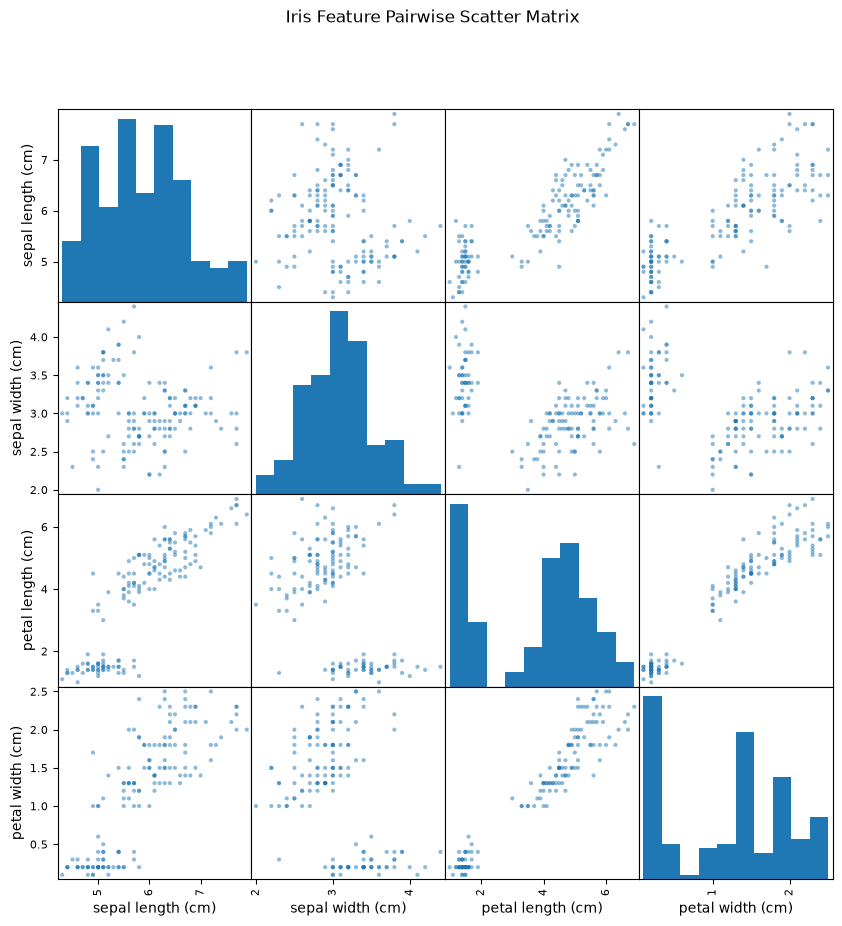

In [4]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

scatter_matrix(X, figsize=(10,10), diagonal='hist')
plt.suptitle("Iris Feature Pairwise Scatter Matrix")
plt.show()

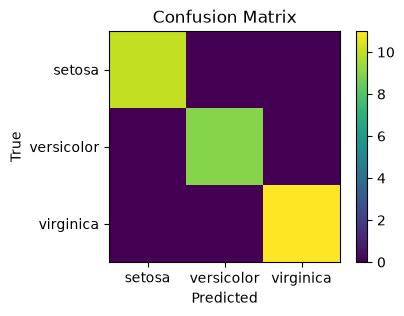

In [5]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(iris.target_names)), iris.target_names)
plt.yticks(range(len(iris.target_names)), iris.target_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()